In [28]:
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [29]:
def plot_bar_chart(df, x, hue, title, facet=None, stacked_by=None):
    plt.figure(figsize=(10,6))
    
    if stacked_by:
        # group and pivot for stacked bar chart (use mean for percentages)
        if facet:
            pivot_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            for fac in df[facet].unique():
                sub = pivot_df[pivot_df[facet] == fac]
                pivot = sub.pivot(index=x, columns=hue, values='value').fillna(0)
                ax = pivot.plot(kind='bar', stacked=True, ax=plt.gca())
                plt.legend(title=stacked_by)
                # add labels to each bar segment
                for cidx, col in enumerate(pivot_df.columns):
                    for ridx, val in enumerate(pivot_df[col]):
                        if val > 0:
                            bottom = pivot_df.iloc[ridx, :cidx].sum()
                            ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
        else: 
            pivot_df = df.groupby([x, hue])['value'].mean().unstack(fill_value=0)
            ax = pivot_df.plot(kind='bar', stacked=True, ax=plt.gca())
            plt.legend(title=stacked_by)
            # add labels to each bar segment
            for cidx, col in enumerate(pivot_df.columns):
                for ridx, val in enumerate(pivot_df[col]):
                    if val > 0:
                        bottom = pivot_df.iloc[ridx, :cidx].sum()
                        ax.text(ridx, bottom + val/2, f"{val:.1f}", ha='center', va='center', fontsize=9, color="white" if val > 5 else "black")
    else:
        # Regular bar chart
        if facet:
            agg_df = df.groupby([x, hue, facet])['value'].mean().reset_index()
            ax = sns.catplot(data=agg_df, x=x, y='value', hue=hue, col=facet, kind='bar', height=5, aspect=1.2)
            ax.set_titles(col_template="{col_name}")

            # add labels on bars
            for ax_i in ax.axes.flatten():
                ax_i.set_ylabel('Average Percentage')
                for container in ax_i.containers:
                    ax_i.bar_label(container, fmt='%.1f', padding=2)
                    
            plt.subplots_adjust(top=0.85)
            plt.suptitle(title)

        else:
            agg_df = df.groupby([x, hue])['value'].mean().reset_index()
            ax = sns.barplot(data=agg_df, x=x, y='value', hue=hue)

            # add labels on bars
            for container in ax.containers:
                ax.bar_label(container, fmt='%.1f', padding=2)
    
            plt.title(title)
            plt.xlabel(x)
            plt.ylabel('Average Percentage')
            plt.tight_layout()
            plt.show()

In [30]:
# Load the Parquet file
df = pq.read_table('data/health-indicators/health_indicator24.parquet').to_pandas()

In [31]:
df.head()

,ref_date,geo,age_group,sex,indigenous_identity,indicators,characteristics,value
0,2015/2018,Canada,"Total, 18 years and over",Both sexes,"Total, Indigenous identity","Perceived health, very good or excellent",Percent,49.6
1,2015/2018,Canada,"Total, 18 years and over",Both sexes,"Total, Indigenous identity","Perceived health, good",Percent,32.1
2,2015/2018,Canada,"Total, 18 years and over",Both sexes,"Total, Indigenous identity","Perceived health, fair or poor",Percent,18.3
3,2015/2018,Canada,"Total, 18 years and over",Both sexes,"Total, Indigenous identity","Perceived mental health, very good or excellent",Percent,59.4
4,2015/2018,Canada,"Total, 18 years and over",Both sexes,"Total, Indigenous identity","Perceived mental health, good",Percent,27.8


# Keep Only Recent Data

In [32]:
df = df[df['ref_date'] == '2019/2022']

In [33]:
df.shape[0]

18103

# Dataframe Pivoting

In [34]:
df['indicators'].unique()

array(['Perceived health, very good or excellent',
       'Perceived health, good', 'Perceived health, fair or poor',
       'Perceived mental health, very good or excellent',
       'Perceived mental health, good',
       'Perceived mental health, fair or poor',
       'Perceived life stress, most days quite a bit or extremely stressful',
       'Body mass index, adjusted self-reported, adult, overweight',
       'Body mass index, adjusted self-reported, adult, obese',
       'Arthritis', 'Diabetes', 'High blood pressure', 'Heart disease',
       'Effects of a stroke', 'Anxiety disorder', 'Mood disorder',
       'Has ever had cancer',
       'At least one underlying chronic health condition',
       'Two or more chronic health conditions',
       'Current smoker, daily or occasional', 'Current smoker, daily',
       'Heavy drinking',
       'Never had alcoholic drinks in the past 12 months',
       'Sense of belonging to local community, somewhat strong or very strong',
       'Life s

In [35]:
# mapping
subgroup_map = {
    'Perceived health': 'Perceived Health Status',
    'Perceived mental health': 'Perceived Mental Health Status',
    'Perceived life stress': 'Life Stress',
    'Body mass index': 'BMI Category',
    'Current smoker': 'Smoking Status',
    'Heavy drinking': 'Alcohol Use',
    'Never had alcoholic drinks in the past 12 months': 'Alcohol Use',
    'At least one underlying chronic health condition': 'Chronic Health Condition Count',
    'Two or more chronic health conditions': 'Chronic Health Condition Count',
    'Arthritis': 'Chronic/Physical Health Condition',
    'Diabetes': 'Chronic/Physical Health Condition',
    'High blood pressure': 'Chronic/Physical Health Condition',
    'Heart disease': 'Chronic/Physical Health Condition',
    'Effects of a stroke': 'Chronic/Physical Health Condition',
    'Anxiety disorder': 'Chronic/Physical Health Condition',
    'Mood disorder': 'Chronic/Physical Health Condition',
    'Has ever had cancer': 'Chronic/Physical Health Condition',
    'Sense of belonging to local community': 'Social Wellbeing',
    'Life satisfaction': 'Social Wellbeing',
    'Has a regular healthcare provider': 'Healthcare Access',
    'Household food insecure': 'Healthcare Access'
}

# create subgroup columns and fill with None
for col in set(subgroup_map.values()):
    df[col] = None

# populate each new column as described
def fill_subgroup(row):
    for key, col in subgroup_map.items():
        if row['indicators'].startswith(key):
            row[col] = row['indicators']
    return row

df_wide = df.apply(fill_subgroup, axis=1)

In [47]:
df_wide.head()

,ref_date,geo,age_group,sex,indigenous_identity,indicators,characteristics,value,chronic_health_condition_count,bmi_category,chronic/physical_health_condition,healthcare_access,smoking_status,life_stress,perceived_health_status,social_wellbeing,alcohol_use,perceived_mental_health_status
18867,2019/2022,Canada,"Total, 18 years and over",Both sexes,"Total, Indigenous identity","Perceived health, very good or excellent",Percent,47.0,None,None,None,None,None,None,"Perceived health, very good or excellent",None,None,None
18868,2019/2022,Canada,"Total, 18 years and over",Both sexes,"Total, Indigenous identity","Perceived health, good",Percent,32.8,None,None,None,None,None,None,"Perceived health, good",None,None,None
18869,2019/2022,Canada,"Total, 18 years and over",Both sexes,"Total, Indigenous identity","Perceived health, fair or poor",Percent,20.3,None,None,None,None,None,None,"Perceived health, fair or poor",None,None,None
18870,2019/2022,Canada,"Total, 18 years and over",Both sexes,"Total, Indigenous identity","Perceived mental health, very good or excellent",Percent,49.3,None,None,None,None,None,None,None,None,None,"Perceived mental health, very good or excellent"
18871,2019/2022,Canada,"Total, 18 years and over",Both sexes,"Total, Indigenous identity","Perceived mental health, good",Percent,30.7,None,None,None,None,None,None,None,None,None,"Perceived mental health, good"


In [37]:
df.shape[0], df_wide.shape[0]

(18103, 18103)

In [38]:
df_wide.columns

Index(['ref_date', 'geo', 'age_group', 'sex', 'indigenous_identity',
       'indicators', 'characteristics', 'value',
       'Chronic Health Condition Count', 'BMI Category',
       'Chronic/Physical Health Condition', 'Healthcare Access',
       'Smoking Status', 'Life Stress', 'Perceived Health Status',
       'Social Wellbeing', 'Alcohol Use', 'Perceived Mental Health Status'],
      dtype='object')

In [71]:
df_wide["ref_date"].unique()

array(['2019/2022'], dtype=object)

# Rename Columns

In [48]:
# rename sex column as gender for consistency
df_wide = df_wide.rename(columns={'sex':'gender'})

In [49]:
# replace space with underscore in column names
df_wide.columns = df_wide.columns.str.replace(' ', '_')

In [50]:
# lowercase all column names
df_wide.columns = df_wide.columns.str.lower()

In [57]:
df_wide.columns

Index(['ref_date', 'geo', 'age_group', 'gender', 'indigenous_identity',
       'indicators', 'characteristics', 'value',
       'chronic_health_condition_count', 'bmi_category',
       'chronic/physical_health_condition', 'healthcare_access',
       'smoking_status', 'life_stress', 'perceived_health_status',
       'social_wellbeing', 'alcohol_use', 'perceived_mental_health_status'],
      dtype='object')

In [59]:
df = df_wide.copy()

# Chronic Health Condition Count

<Figure size 1000x600 with 0 Axes>

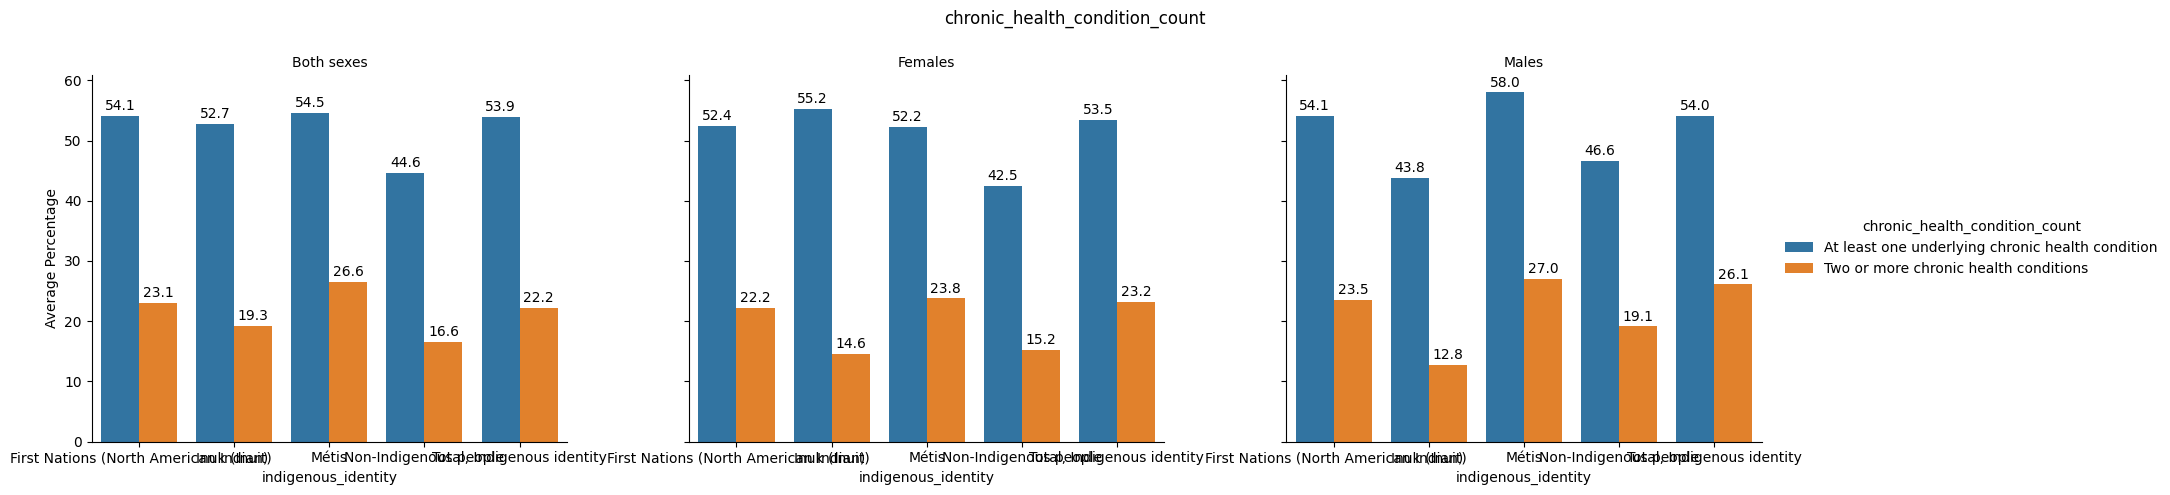

In [60]:
plot_bar_chart(df, 'indigenous_identity', 'chronic_health_condition_count', "chronic_health_condition_count", 'gender', stacked_by=False)

<Figure size 1000x600 with 0 Axes>

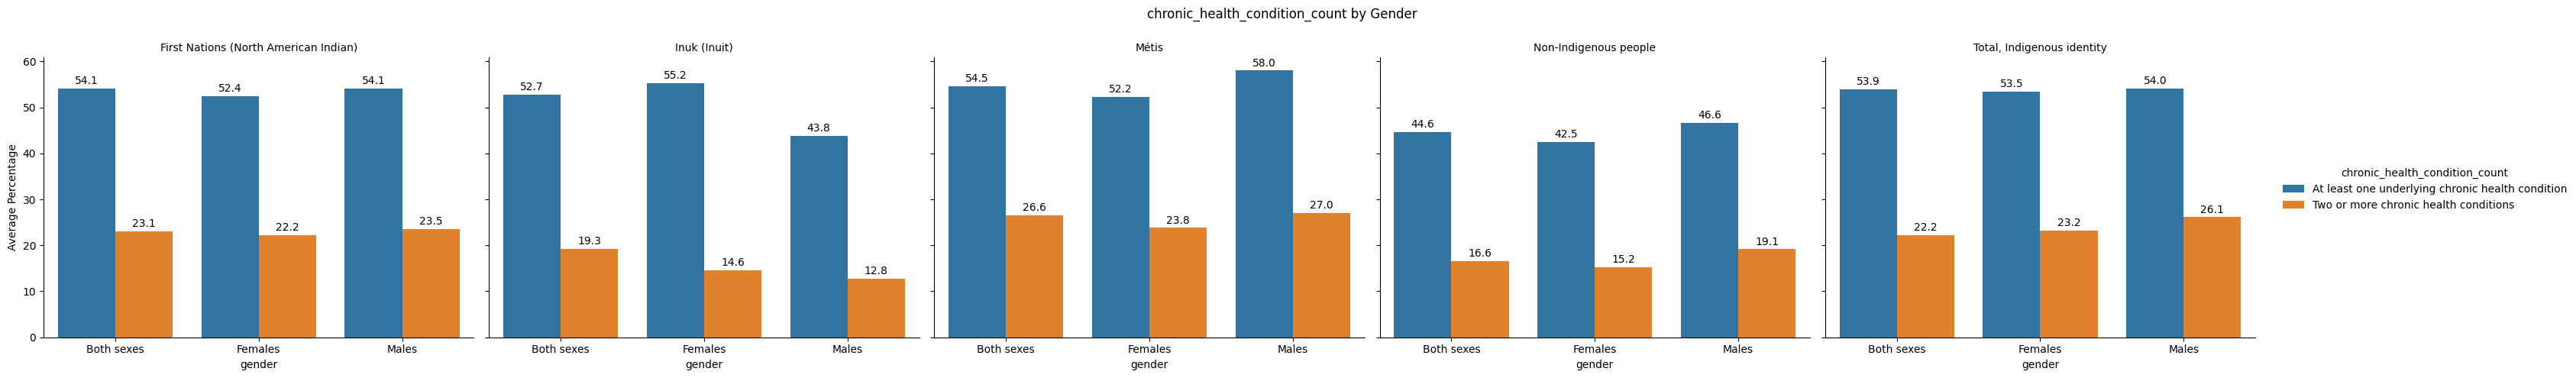

In [61]:
plot_bar_chart(df, 'gender', 'chronic_health_condition_count', "chronic_health_condition_count by Gender", 'indigenous_identity', stacked_by=False)

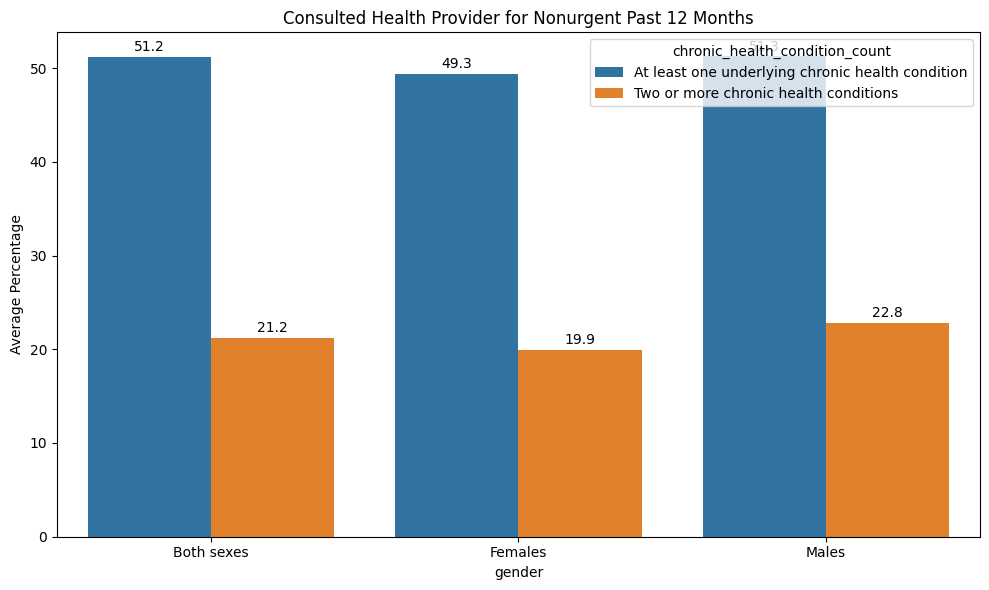

In [62]:
plot_bar_chart(df, 'gender', 'chronic_health_condition_count', "Consulted Health Provider for Nonurgent Past 12 Months", stacked_by=False)

# BMI Category

In [64]:
df.columns

Index(['ref_date', 'geo', 'age_group', 'gender', 'indigenous_identity',
       'indicators', 'characteristics', 'value',
       'chronic_health_condition_count', 'bmi_category',
       'chronic/physical_health_condition', 'healthcare_access',
       'smoking_status', 'life_stress', 'perceived_health_status',
       'social_wellbeing', 'alcohol_use', 'perceived_mental_health_status'],
      dtype='object')

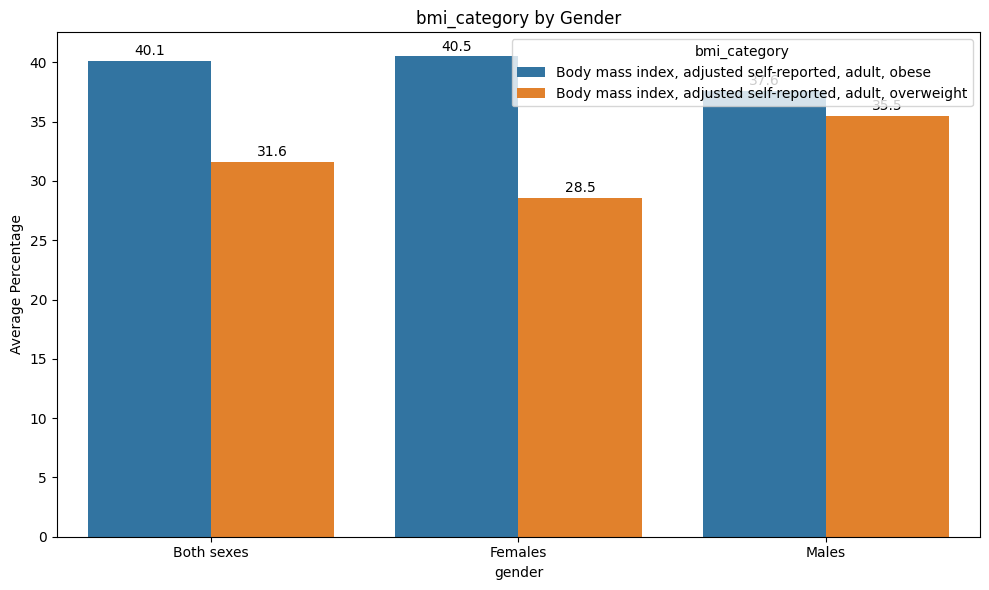

In [66]:
plot_bar_chart(df, 'gender', 'bmi_category', "bmi_category by Gender", stacked_by=False)

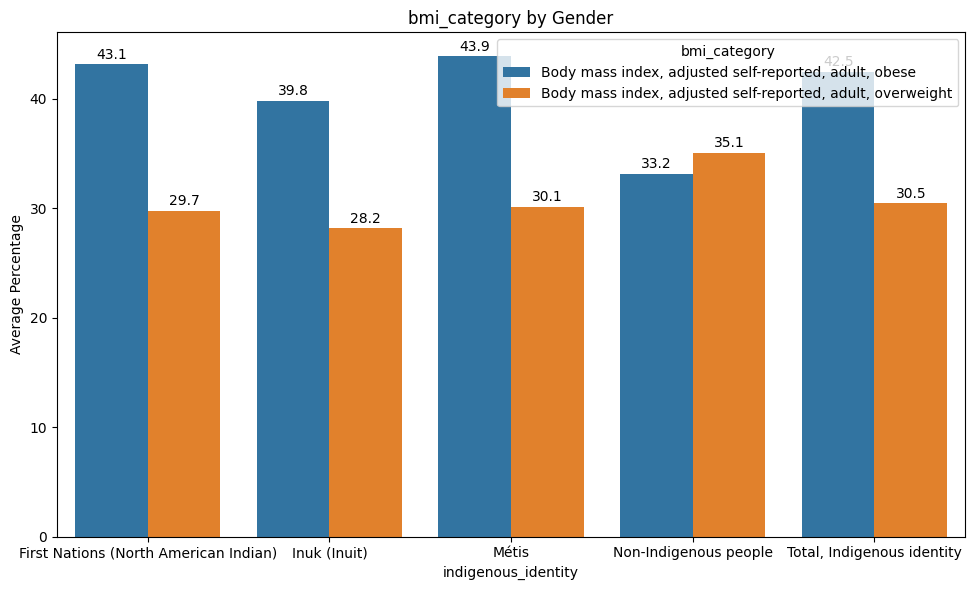

In [67]:
plot_bar_chart(df, 'indigenous_identity', 'bmi_category', "bmi_category by Gender", stacked_by=False)

# Discrimination

In [68]:
plot_cols = ['chronic/physical_health_condition', 'healthcare_access',
       'smoking_status', 'life_stress', 'perceived_health_status',
       'social_wellbeing', 'alcohol_use', 'perceived_mental_health_status']

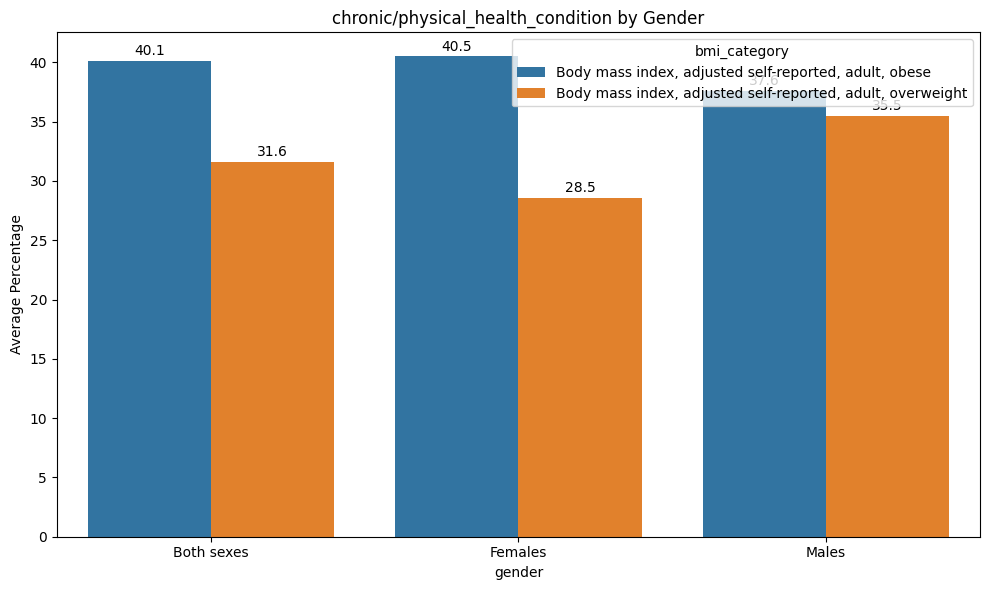

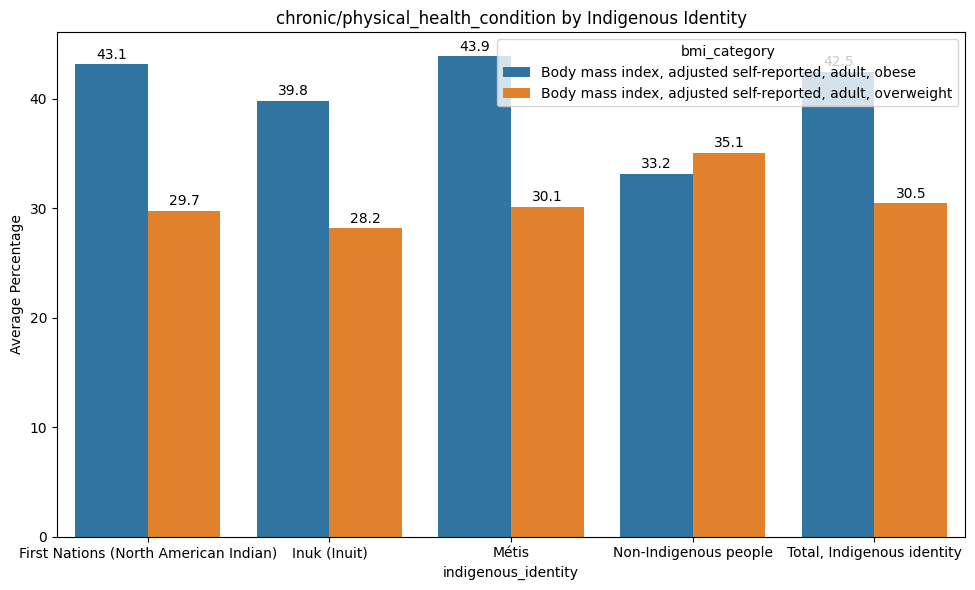

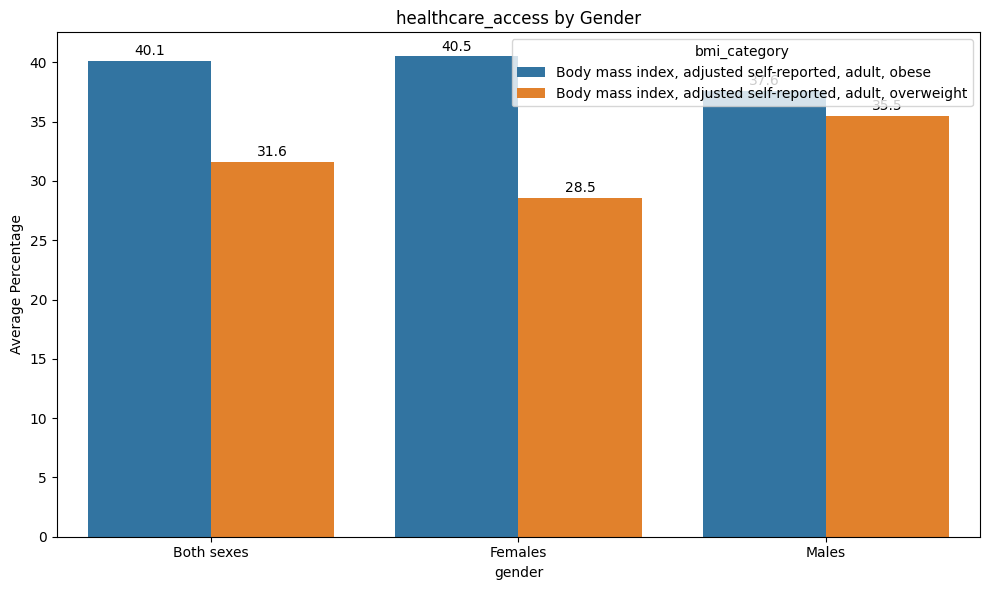

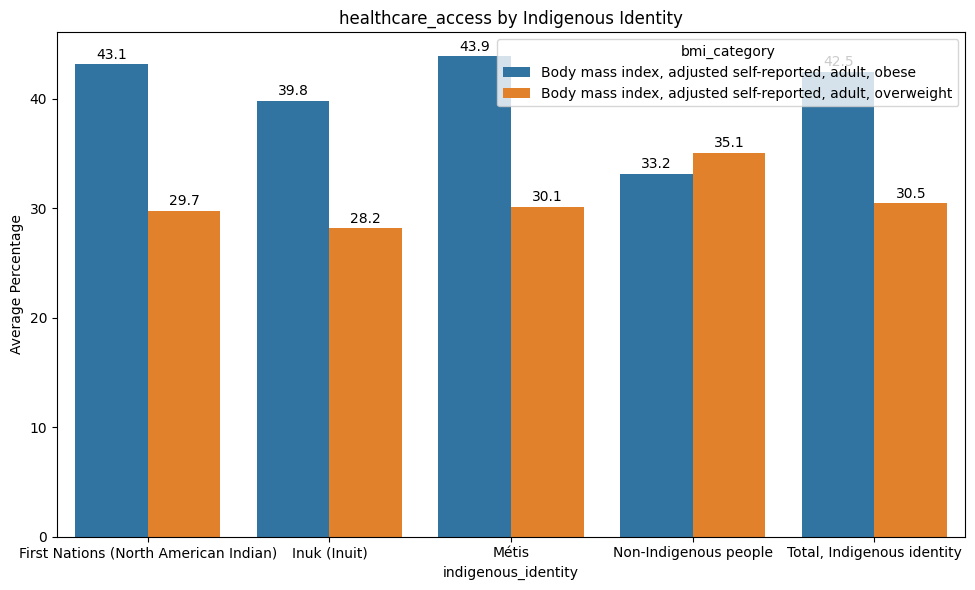

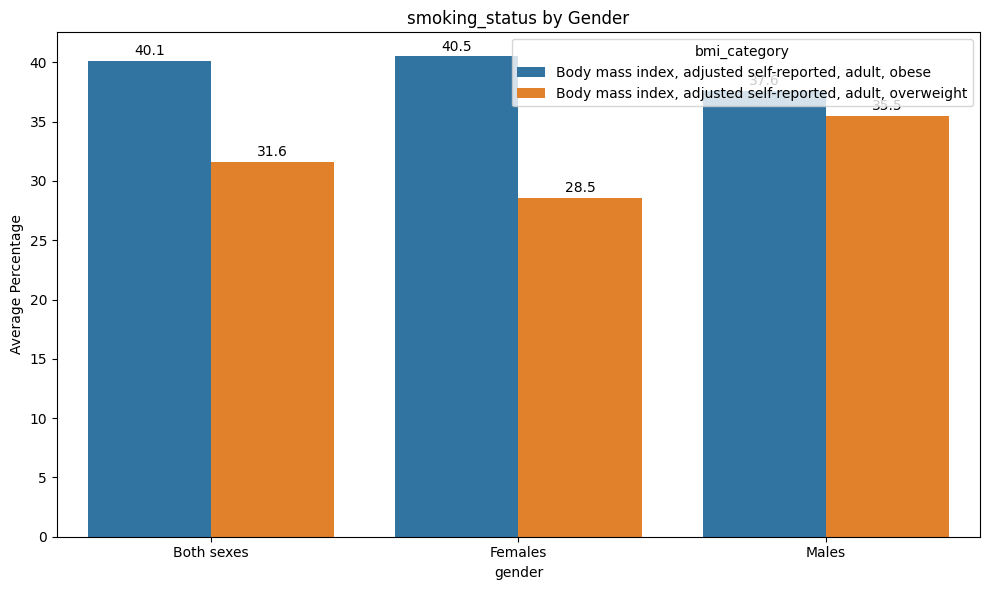

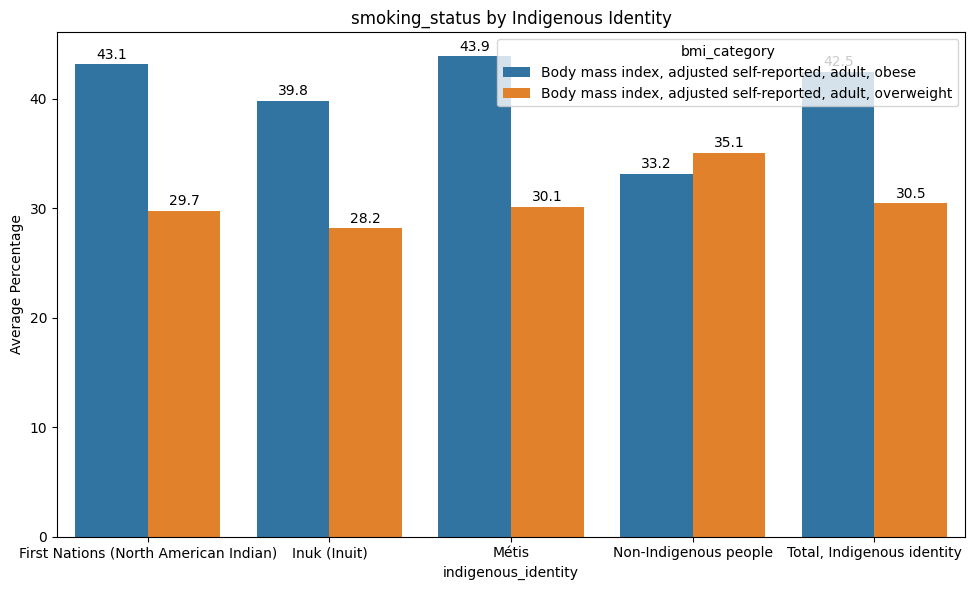

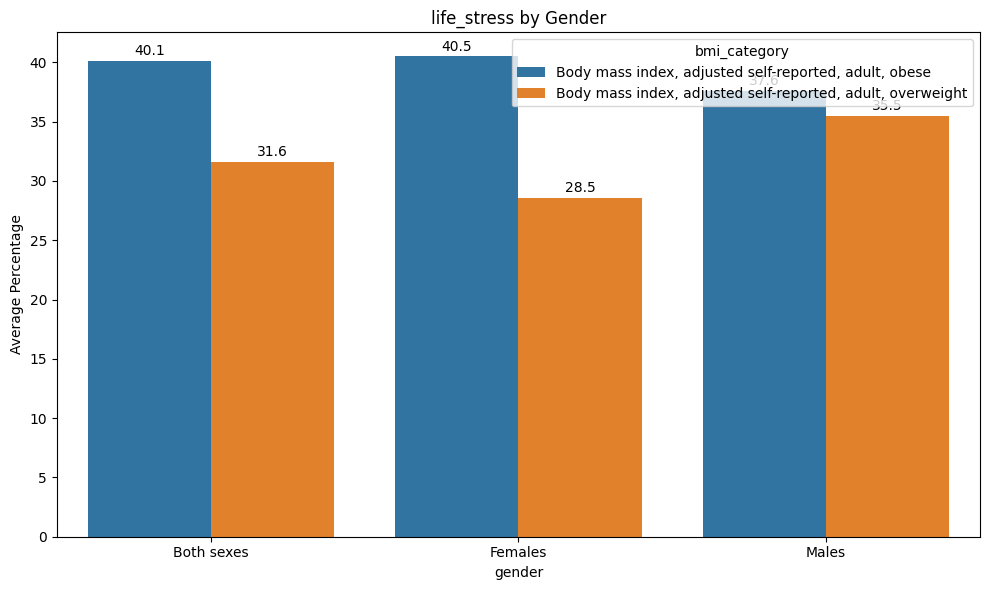

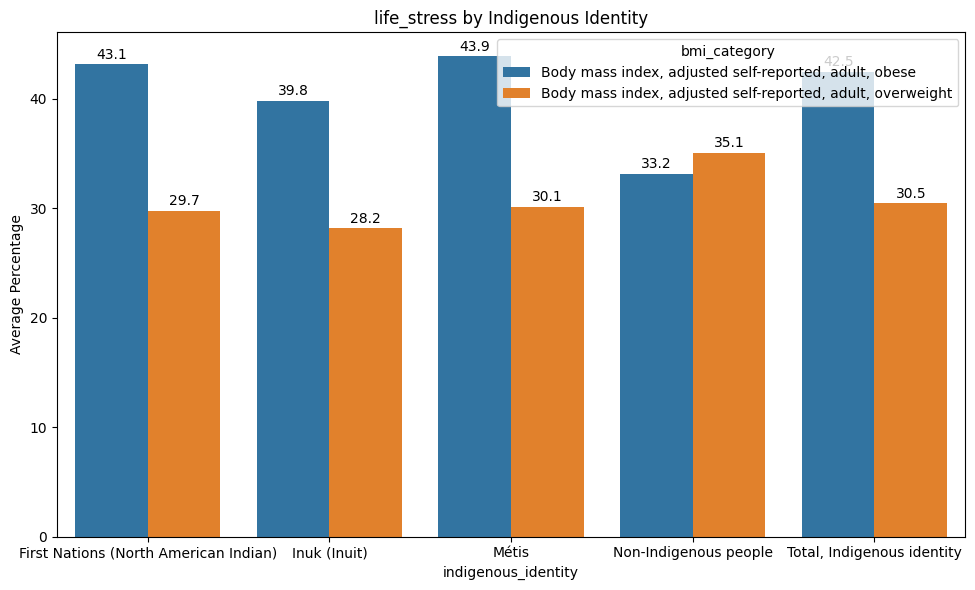

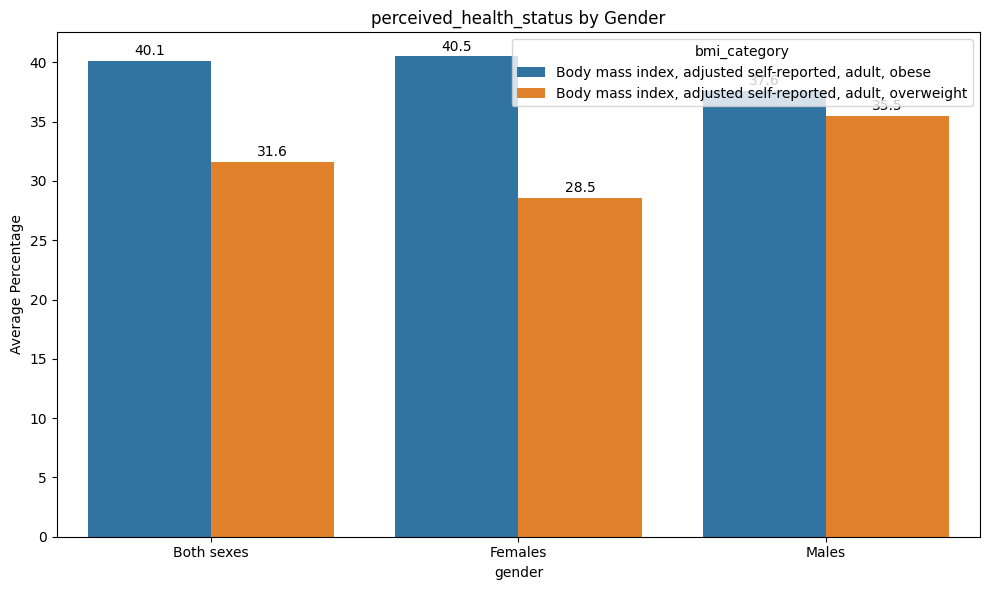

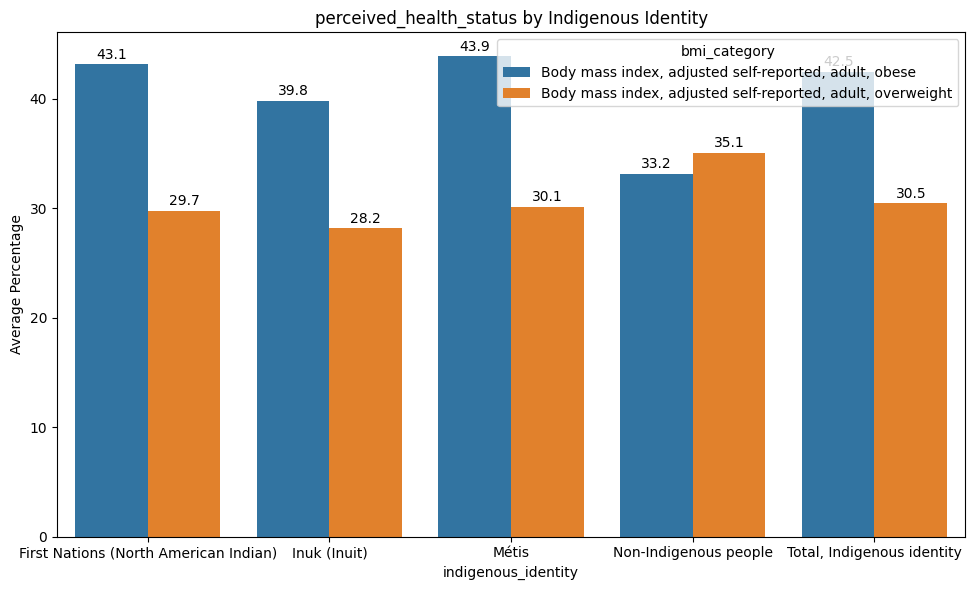

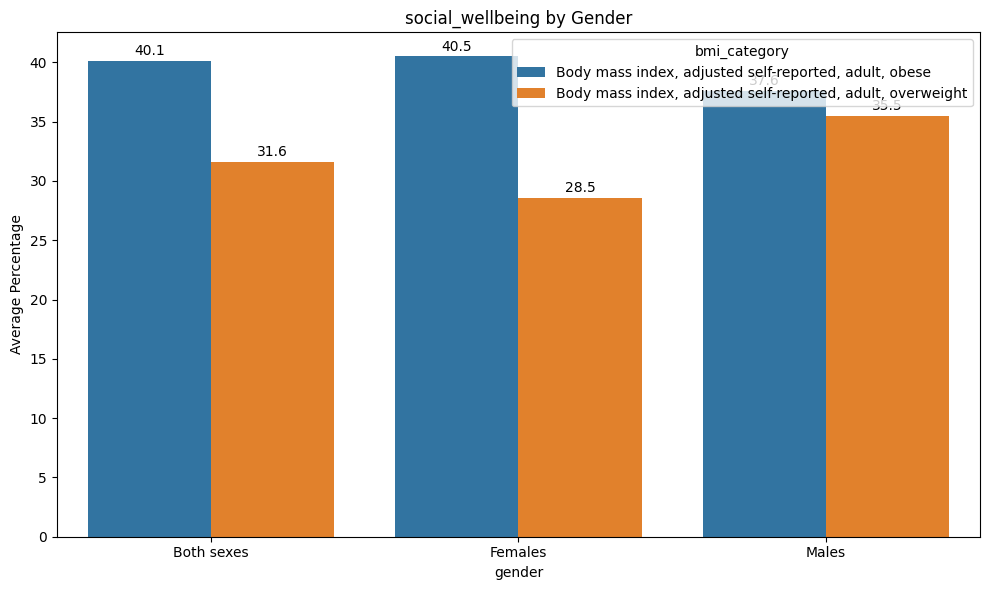

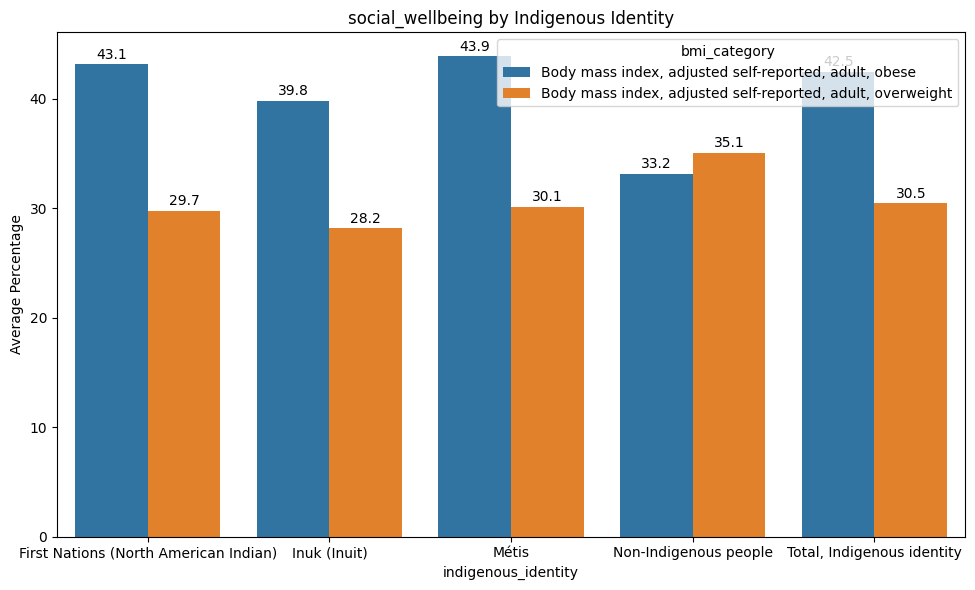

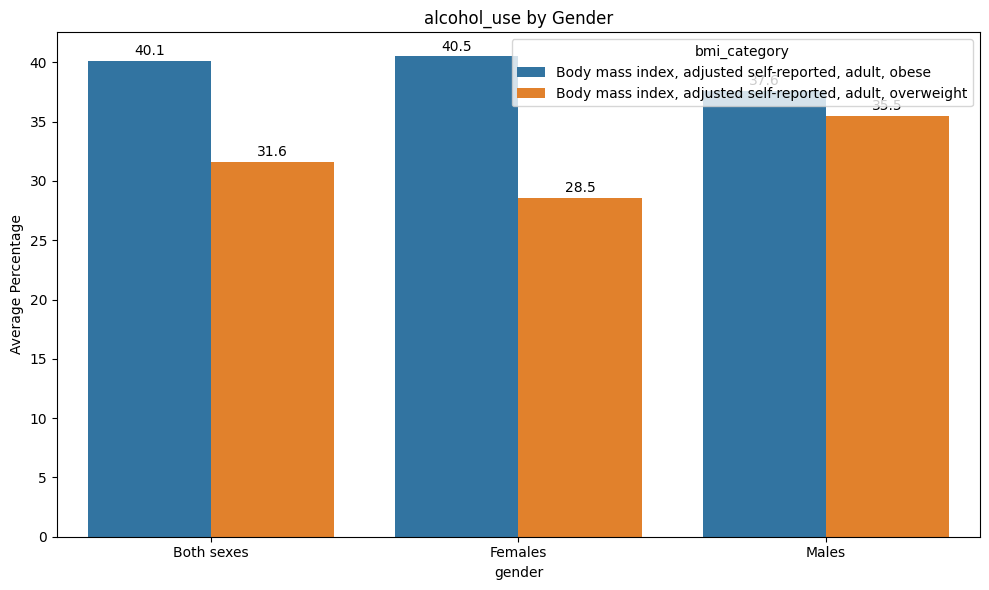

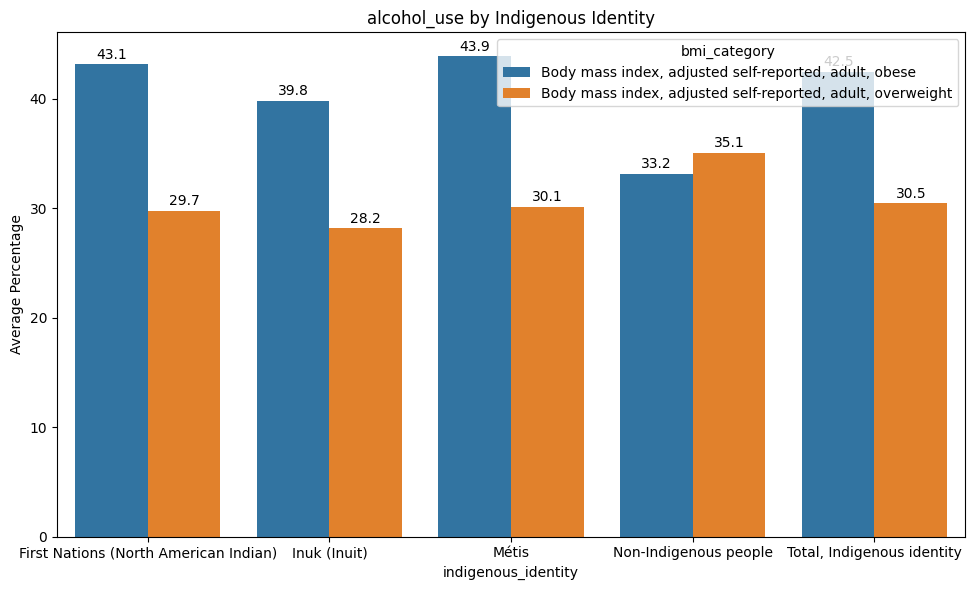

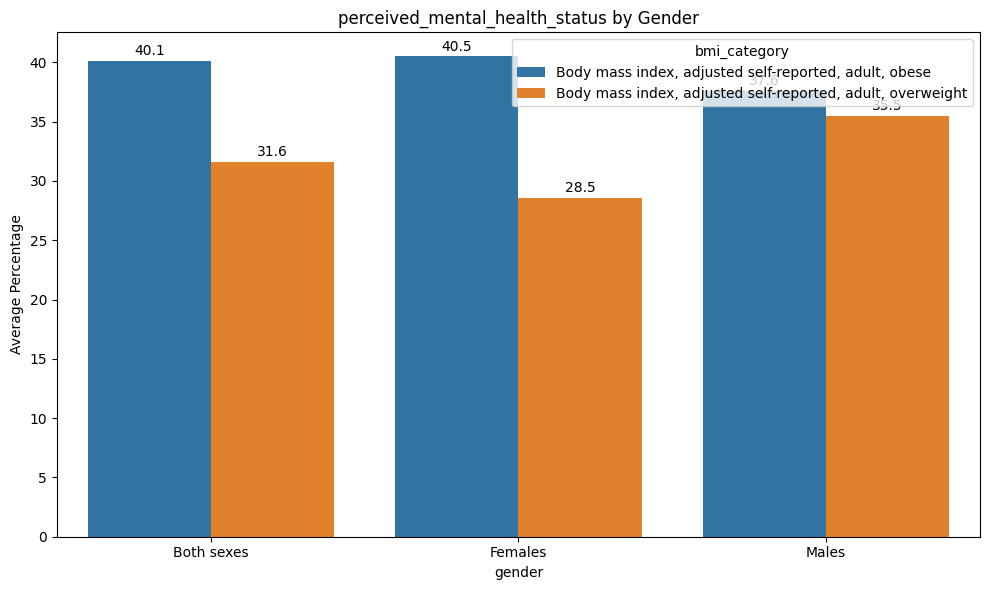

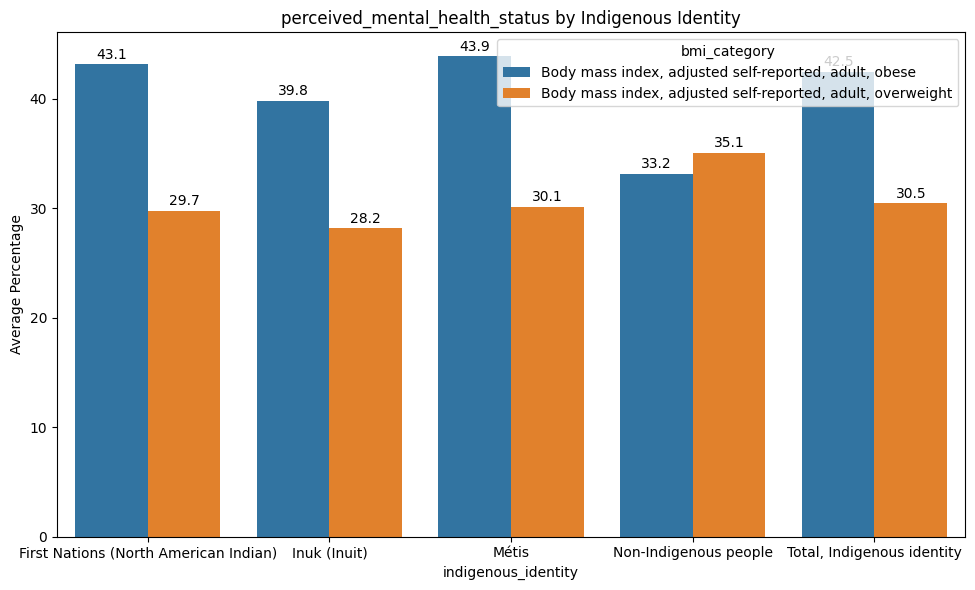

In [70]:
for col in plot_cols:
    plot_bar_chart(df, 'gender', 'bmi_category', col+" by Gender", stacked_by=False)
    plot_bar_chart(df, 'indigenous_identity', 'bmi_category', col+" by Indigenous Identity", stacked_by=False)